<h2 style="color: white; font-size: 22px; text-align: center;">
  Random Forest estandarizado semanal
</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_log_error
from sklearn.metrics import r2_score  

In [2]:
datos = pd.read_csv("/home/santiago/Desktop/PROYECTO_RF/ESTANDARIZADO/DATOS_1/df_RobustScaler_semanal.csv")
datos["fecha"] = pd.to_datetime(datos["fecha"])

In [3]:
def crear_features(df, variables):
    df = df.copy()

    for var in variables:

        # Lags
        for lag in [1, 2, 4, 8]:
            df[f"{var}_lag{lag}"] = df[var].shift(lag)

        df[f"{var}_diff1"] = df[var] - df[var].shift(1)
        df[f"{var}_diff4"] = df[var] - df[var].shift(4)

        # Medias móviles
        df[f"{var}_ma4"] = df[var].rolling(4).mean()
        df[f"{var}_ma8"] = df[var].rolling(8).mean()

        # Tendencia
        df[f"{var}_trend4"] = df[var].rolling(4).apply(
            lambda x: np.polyfit(range(len(x)), x, 1)[0],
            raw=True
        )

    df = df.dropna().reset_index(drop=True)
    return df

In [4]:
def modelo_random_forest(dataframe, variable_objetivo):

    print("=" * 60)
    print(f"Modelo para predecir: {variable_objetivo}")
    print("=" * 60)

   #separar datos de entrenamiento y prueba
    X = dataframe.drop(columns=["fecha", variable_objetivo])
    y = dataframe[variable_objetivo]

    #separacion temporal
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        shuffle=False
    )

    # Fechas del conjunto de prueba
    fechas_test = dataframe["fecha"].iloc[len(X_train):]

    #random forest
    modelo = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
    )

    modelo.fit(X_train, y_train)

    #prediccion
    pred = modelo.predict(X_test)

    residuos = y_test - pred
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    print(f"RMSE = {rmse:.3f}")
    print(f"MAE = {mae:.3f}")
    print(f"R2 = {r2:.3f}")

    #importancia de variables
    importancia = pd.DataFrame({
        "Variable": X.columns,
        "Importancia": modelo.feature_importances_
    }).sort_values("Importancia", ascending=False)

    print("\nTop variables:")
    print(importancia.head(10))

    #grafica
    plt.figure(figsize=(12,5))

    plt.plot(fechas_test, y_test.values, label="Real")
    plt.plot(fechas_test, pred, label="Predicción")

    plt.title(f"Random Forest - {variable_objetivo}")
    plt.xlabel("Fecha")
    plt.ylabel(variable_objetivo)

    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12,4))
    plt.plot(fechas_test, residuos)
    plt.axhline(0, color='red', linestyle='--')
    plt.title("Residuos")
    plt.grid(True)
    plt.show()
    
    return modelo

In [5]:
variables = [
    "pm25", "pm10", "nox", "so2",
    "no2", "o3", "co", "rh",
    "wsp", "wdr", "tmp", "pa"
]

datos_feat = crear_features(datos, variables)

/tmp/ipykernel_23111/3761943721.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_trend4"] = df[var].rolling(4).apply(
/tmp/ipykernel_23111/3761943721.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_lag{lag}"] = df[var].shift(lag)
/tmp/ipykernel_23111/3761943721.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragme

Modelo para predecir: pm25
RMSE = 0.418
MAE = 0.328
R2 = 0.802

Top variables:
       Variable  Importancia
10           pa     0.714901
7           wsp     0.036540
15   pm25_diff1     0.035543
17     pm25_ma4     0.028661
16   pm25_diff4     0.025475
19  pm25_trend4     0.022928
11    pm25_lag1     0.007534
1           nox     0.005992
12    pm25_lag2     0.004603
2           so2     0.003831


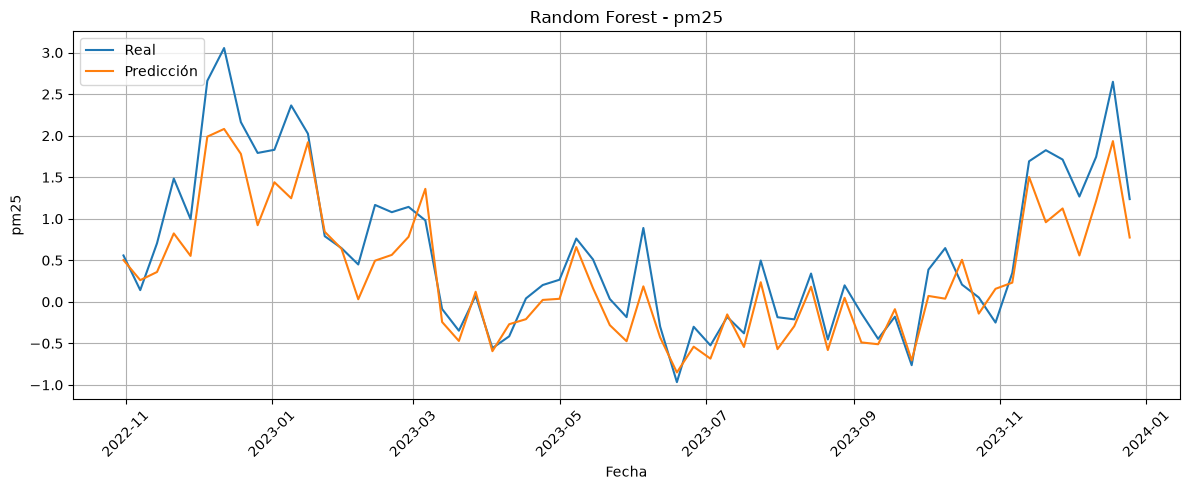

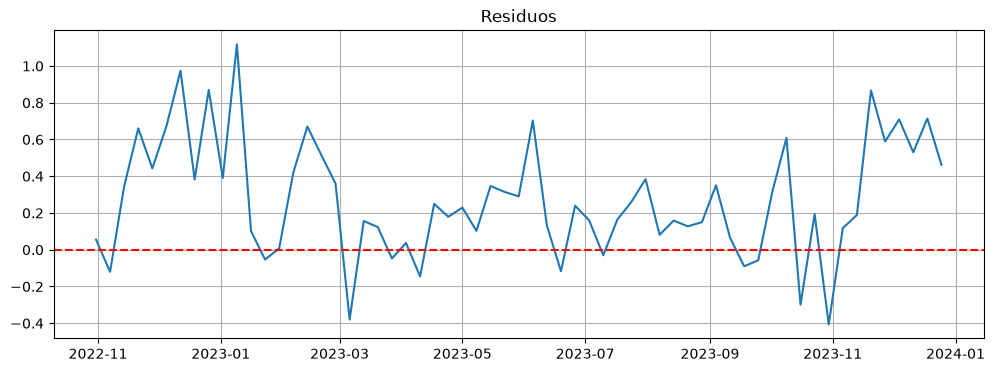

In [6]:
modelo_random_forest(datos_feat, "pm25")
print()

Modelo para predecir: nox
RMSE = 0.299
MAE = 0.215
R2 = 0.859

Top variables:
      Variable  Importancia
10          pa     0.276955
34   nox_diff4     0.168073
0         pm25     0.107872
33   nox_diff1     0.085976
7          wsp     0.065321
35     nox_ma4     0.064191
37  nox_trend4     0.061561
31    nox_lag4     0.018622
4           o3     0.005091
47    no2_lag1     0.004287


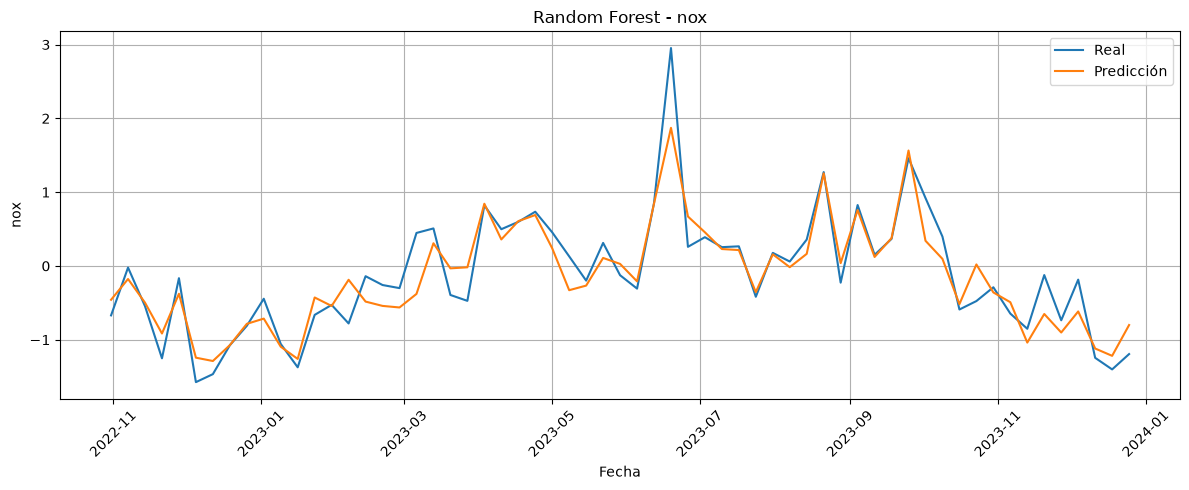

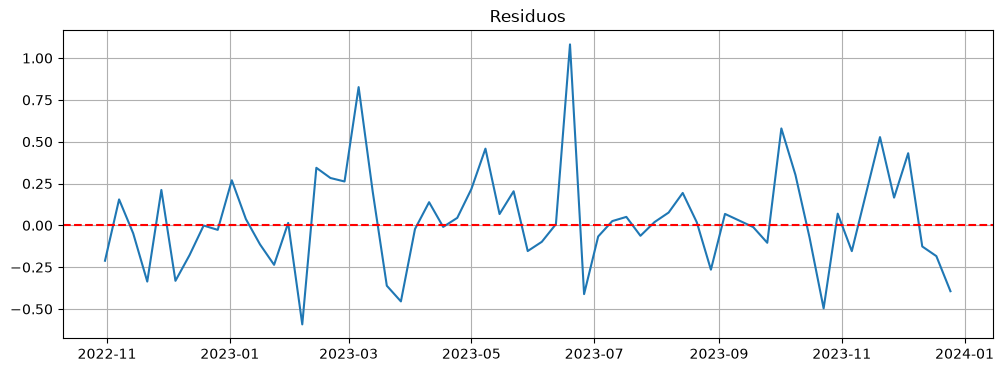

In [7]:
modelo_random_forest(datos_feat, "nox")
print()

Modelo para predecir: o3
RMSE = 0.193
MAE = 0.156
R2 = 0.884

Top variables:
        Variable  Importancia
62        o3_ma4     0.668427
64     o3_trend4     0.077249
60      o3_diff1     0.056404
4            no2     0.026337
61      o3_diff4     0.024338
51     no2_diff1     0.007220
56       o3_lag1     0.007000
8            wdr     0.006203
116       pa_ma4     0.004504
28   pm10_trend4     0.004469


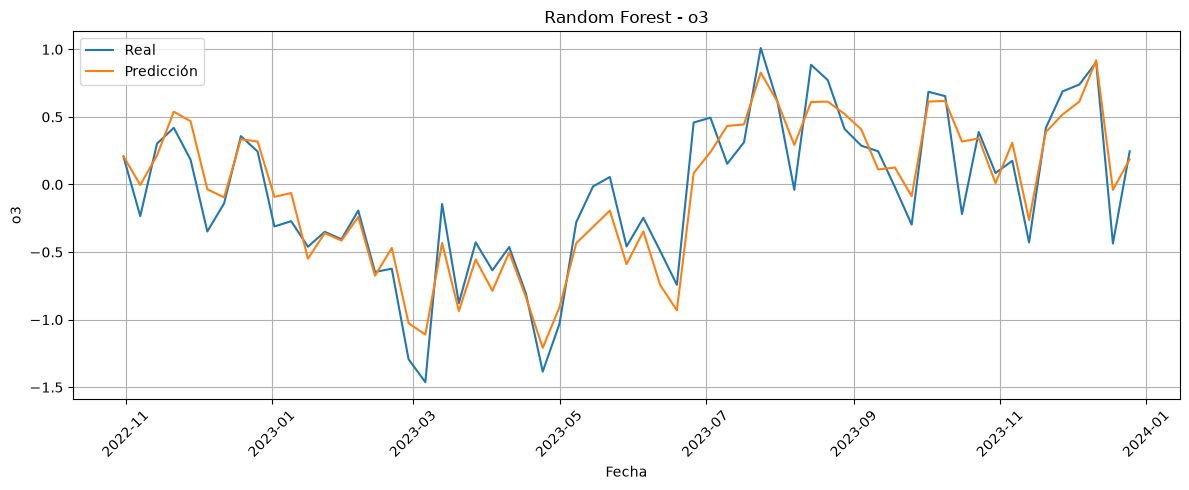

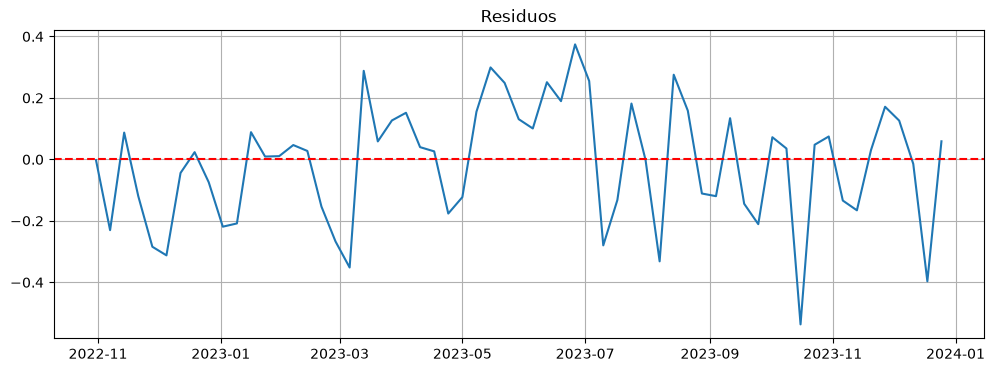

In [8]:
modelo_random_forest(datos_feat, "o3")
print()